In [1]:
import numpy as np
from scipy.linalg import eigh

# ---------- Parameters ----------
# hbar = 1   # Reduced Planck constant in J·s
# m0 = 1  # Electron rest mass in kg
# a0 = 1  # Bohr radius in meters
# energy_scale = 27.2113862 * hbar **2 / m0 / a0**2  # Conversion factor from hbar^2/m_e/a_0^2 to eV

e = 1.6e-19 # Elementary charge in Coulombs
hbar = 1.05e-34 # Reduced Planck constant in J·s
m0 = me = 9.1e-31 # Electron rest mass in kg
a0 = 5.29e-11 # Bohr radius in meters
# energy_scale = 27.2113862 * hbar **2 / m0 / a0**2  # Conversion factor from hbar^2/m_e/a_0^2 to eV

params = {
    "p_perp": 0.4829 * hbar / a0/(e*1e-10),
    "p_parallel": 0.6431 * hbar / a0/(e*1e-10),
    "A_c2_perp": 4.1565 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_c1_perp": 9.5120 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_c2_parallel": 2.4091 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_c1_parallel": 1 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_1": -4.3636 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_2": -2.0833 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_3": 2.4545 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_4": -2.7504 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_5": 2.7232 * hbar**2 / (2 * m0)/(e*1e-20),
    "A_6": -3.5421 * hbar**2 / (2 * m0)/(e*1e-20),
    "Delta_1": 0.2688 ,
    "Delta_2": 0.0934 ,
    "Delta_3": 0.0908 ,
    "Ecbp1": 0.632 ,
    "Ecb": 0.298 ,
    "Ev": -0.3622 ,
    "hbar": hbar,
    "m0": m0,
}

# ---------- Hamiltonian builder ----------
def Hhex(kx, ky, kz, p=params):
    k_plus = kx + 1j*ky
    k_minus = kx - 1j*ky

    C1 = p["A_c1_perp"]*(kx**2 + ky**2) + p["A_c1_parallel"]*kz**2
    C2 = p["A_c2_perp"]*(kx**2 + ky**2) + p["A_c2_parallel"]*kz**2
    beta = p["A_1"]*kz**2 + p["A_2"]*(kx**2 + ky**2)
    alpha = p["A_3"]*kz**2 + p["A_4"]*(kx**2 + ky**2)

    kin = 0

    H = np.zeros((10,10), dtype=complex)

    H[0,0] = kin + C2 + p["Ecbp1"]
    H[0,2] = -(np.sqrt(2)*p["hbar"]*k_plus*p["p_perp"])/(2*p["m0"])
    H[0,3] = (np.sqrt(2)*p["hbar"]*k_minus*p["p_perp"])/(2*p["m0"])
    H[0,4] = (p["hbar"]*kz*p["p_parallel"])/p["m0"]

    H[1,1] = kin + C1 + p["Ecb"]

    H[2,0] = -(np.sqrt(2)*p["hbar"]*k_minus*p["p_perp"])/(2*p["m0"])
    H[2,2] = kin + p["Delta_1"] + p["Delta_2"] + p["Ev"] + alpha + beta
    H[2,3] = -p["A_5"]*k_minus**2
    H[2,4] = -p["A_6"]*k_minus*kz

    H[3,0] = (np.sqrt(2)*p["hbar"]*k_plus*p["p_perp"])/(2*p["m0"])
    H[3,2] = -p["A_5"]*k_plus**2
    H[3,3] = kin + p["Delta_1"] - p["Delta_2"] + p["Ev"] + alpha + beta
    H[3,4] = p["A_6"]*k_plus*kz
    H[3,9] = np.sqrt(2)*p["Delta_3"]

    H[4,0] = (p["hbar"]*kz*p["p_parallel"])/p["m0"]
    H[4,2] = -p["A_6"]*k_plus*kz
    H[4,3] = p["A_6"]*k_minus*kz
    H[4,4] = kin + p["Ev"] + beta
    H[4,8] = np.sqrt(2)*p["Delta_3"]

    H[5,5] = kin + C2 + p["Ecbp1"]
    H[5,7] = (np.sqrt(2)*p["hbar"]*k_minus*p["p_perp"])/(2*p["m0"])
    H[5,8] = -(np.sqrt(2)*p["hbar"]*k_plus*p["p_perp"])/(2*p["m0"])
    H[5,9] = (p["hbar"]*kz*p["p_parallel"])/p["m0"]

    H[6,6] = kin + C1 + p["Ecb"]

    H[7,5] = (np.sqrt(2)*p["hbar"]*k_plus*p["p_perp"])/(2*p["m0"])
    H[7,7] = kin + p["Delta_1"] + p["Delta_2"] + p["Ev"] + alpha + beta
    H[7,8] = -p["A_5"]*k_plus**2
    H[7,9] = p["A_6"]*k_plus*kz

    H[8,4] = np.sqrt(2)*p["Delta_3"]
    H[8,5] = -(np.sqrt(2)*p["hbar"]*k_minus*p["p_perp"])/(2*p["m0"])
    H[8,7] = -p["A_5"]*k_minus**2
    H[8,8] = kin + p["Delta_1"] - p["Delta_2"] + p["Ev"] + alpha + beta
    H[8,9] = -p["A_6"]*k_minus*kz

    H[9,3] = np.sqrt(2)*p["Delta_3"]
    H[9,5] = (p["hbar"]*kz*p["p_parallel"])/p["m0"]
    H[9,7] = p["A_6"]*k_minus*kz
    H[9,8] = -p["A_6"]*k_plus*kz
    H[9,9] = kin + p["Ev"] + beta

    # Hermitianize (safeguard against numerical asymmetry)
    H = (H + H.conj().T)/2

    return H

# ---------- gap calculation at Gamma----------

kx, ky, kz = 0, 0, 0
H = Hhex(kx, ky, kz, p = params)
evals, evecs = eigh(H)
evals = np.real(evals)
conduction_band_min = evals[6] # conducton band minimum  
valence_band_max = evals[5]    # valence band maximum
band_gap = conduction_band_min - valence_band_max
print(f"Band gap at Gamma point: {band_gap:.3f} eV")

# print("\n hamiltonian at gamma:")
# print(Hhex(0, 0, 0, p = params).round(8))



Band gap at Gamma point: 0.298 eV


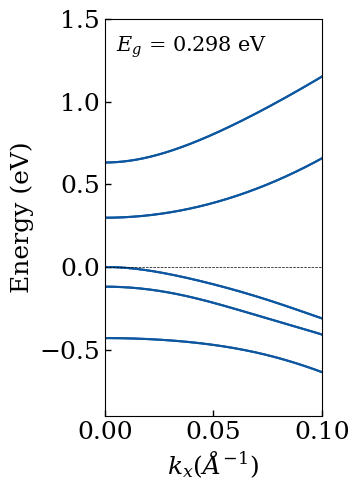

In [2]:
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.autolayout': True})
plt.figure(figsize=(3.7, 5))
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

nk = 1000
div = 16
Mpoint = np.array([np.pi, 0.0, 0.0])
GM = np.array([[i, 0, 0] for i in np.arange(0, Mpoint[0] / div, Mpoint[0] / (div * nk))])
k_points = GM[:, 0]

# Compute eigenvalues for analytical model
eigvals = [eigh(Hhex(kx, ky, kz))[0] for kx, ky, kz in GM]

# === Plot kp model ===
cmap = plt.cm.Blues
colors = cmap([0.85, 0.65, 0.45])

# === Plot kp model ===
for i, band in enumerate(np.array(eigvals).T):
    plt.plot(k_points, band, color= colors[0], lw=1.5, label="k.p"  if i == 1 else "")
plt.axhline(y=0, color='black', ls='--', lw=0.5)
plt.xlabel(r"$k_x (\AA^{-1})$", fontsize=18)
plt.ylabel("Energy (eV)", fontsize=18)
# plt.ylim(-5, 0)
# plt.xlim(0.0, 0.005)
plt.ylim(-0.9, 1.5)
plt.xlim(0.0, 0.1)
# plt.xticks([0.0, 0.05, 0.1], [0.0, 0.05, 0.1])
# plt.grid(True, linestyle='--', alpha=0.3)
plt.tick_params(direction='in', length=4, width=1, labelsize=18)
# plt.legend(frameon=False, fontsize=10, loc='upper left')
plt.text(0.005,1.3,"$E_g$ = 0.298 eV",  fontsize = 15)

plt.tight_layout()
plt.savefig("hamiltonian_check.png", dpi=300)
plt.savefig("hamiltonian_check.pdf", dpi=300)
plt.show()

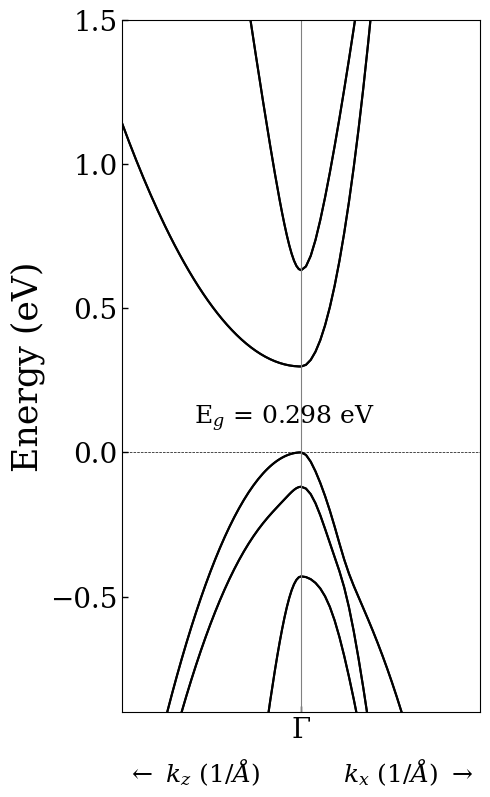

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.linalg import eigh

# ================== Plot settings ==================
plt.rcParams.update({'figure.autolayout': True})
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

# ================== k-points ==================
nk = 500  # points per segment

Apoint = np.array([0.0, 0.0, np.pi])
Gpoint = np.array([0.0, 0.0, 0.0])
Mpoint = np.array([np.pi, -np.pi*np.sqrt(3), 0.0])

# ---- A → Γ ----
AG = np.array([
    Apoint + (Gpoint - Apoint) * t
    for t in np.linspace(0, 1, nk)
])

# ---- Γ → M ----
GM = np.array([
    Gpoint + (Mpoint - Gpoint) * t
    for t in np.linspace(0, 1, nk)
])

# ---- Full path ----
k_path = np.vstack((AG, GM))

# ================== k-distance ==================
k_dist = np.zeros(len(k_path))
for i in range(1, len(k_path)):
    k_dist[i] = k_dist[i-1] + np.linalg.norm(k_path[i] - k_path[i-1])

# ================== Eigenvalues ==================
# Ensure Hhex(kx, ky, kz) is defined
eigvals = [eigh(Hhex(kx, ky, kz))[0] for kx, ky, kz in k_path]
eigvals = np.array(eigvals)

# ================== Plot ==================
plt.figure(figsize=(5, 8))

for band in eigvals.T:
    plt.plot(k_dist, band, color="k", lw=1.5)

# Fermi level
plt.axhline(y=0, color='black', ls='--', lw=0.5)

# High-symmetry index
idx_G = nk - 1

# ---- Zoom around Γ ----
window = 0.05 * (k_dist[-1] - k_dist[0])
plt.xlim(k_dist[idx_G] - window, k_dist[idx_G] + window)

# ---- Only Γ tick ----
plt.xticks([k_dist[idx_G]], [r"$\Gamma$"], fontsize=20)

# Vertical line at Γ
plt.axvline(k_dist[idx_G], color='gray', lw=0.8)

# ---- Directional labels ----
ymin, ymax = -0.9, 1.5
plt.ylim(ymin, ymax)

plt.text(k_dist[idx_G] + 0.6*window, ymin - 0.1*(ymax - ymin),
         r"$k_x$ (1/$\AA$) $\rightarrow$", fontsize=18, ha='center')

plt.text(k_dist[idx_G] - 0.6*window, ymin - 0.1*(ymax - ymin),
         r"$\leftarrow$ $k_z$ (1/$\AA$)", fontsize=18, ha='center')

# Labels
plt.ylabel("Energy (eV)", fontsize=25)

plt.tick_params(direction='in', length=4, width=1, labelsize=20)

# Band gap annotation
plt.text(k_dist[idx_G] - 0.6*window, 0.1, "E$_g$ = 0.298 eV", fontsize=18)

# Save
plt.tight_layout()
plt.savefig("band_AGM_zoom_gamma_directional.png", dpi=300)
plt.savefig("band_AGM_zoom_gamma_directional.pdf", dpi=300)

plt.show()

In [4]:
print(eigh(Hhex(0, 0, 0))[0])
cbm = evals[6]
vbm = evals[5]
gap = cbm - vbm
print(f"cbm: {cbm}, vbm: {vbm}, gap: {gap}")

[-4.30001029e-01 -4.30001029e-01 -1.18998971e-01 -1.18998971e-01
 -5.55111512e-17 -5.55111512e-17  2.98000000e-01  2.98000000e-01
  6.32000000e-01  6.32000000e-01]
cbm: 0.298, vbm: -5.551115123125783e-17, gap: 0.29800000000000004


In [5]:
# =============================================================================
# define parameters form table 2
# =============================================================================

e = 1.6e-19
hbar = 1.05e-34
m0 = me = 9.1e-31 
a0 = 5.29e-11
Ev = -0.3622
Ecb1 = 0.632 
Ecb = 0.298


"""Optical transition matrix elements"""
P_perp = 0.4829 * hbar/a0
P_par = 0.6431 * hbar/a0
p1 = - 1j * hbar / me * P_par/(e*1e-10)
p2 = - 1j * hbar / me * P_perp/(e*1e-10)

"""conduction band effective parameters"""
eff_mass_unit = hbar**2/(2*m0)
Ac1par = 1.0 * eff_mass_unit/(e*1e-20)
Ac2perp = 4.1565 * eff_mass_unit/(e*1e-20)
Ac1perp = 9.5120 * eff_mass_unit/(e*1e-20)
Ac2par = 2.4091 * eff_mass_unit/(e*1e-20)

"""valance band effective parameters"""
A1 = -4.3636 * eff_mass_unit/(e*1e-20)
A2 = -2.0833 * eff_mass_unit/(e*1e-20)
A3 = 2.4545 * eff_mass_unit/(e*1e-20)
A4 = -2.7504 * eff_mass_unit/(e*1e-20)
A5 = 2.7232 * eff_mass_unit/(e*1e-20)
A6 = -3.5421 * eff_mass_unit/(e*1e-20)

"""Energy splittings"""
delta1 = deltacf = 0.2688 
delta2 = 0.0934
delta3 = 0.0908

# =============================================================================
# Create the H_kane matrix
# =============================================================================


def H_kane(kx, ky, kz):
    
    h_ke =  hbar**2 * (kx**2 + ky**2 + kz**2) / (2 * m0)/(e*1e-20) * np.eye(10)
    
    hup = np.array([
        [Ecb1, 0, -1/np.sqrt(2)*p2*(kx + 1j * ky), -1/np.sqrt(2)*p2*(kx - 1j * ky), 1j*p1*kz],
        [0,Ecb,0,0,0],
        [1/np.sqrt(2)*p2*(kx - 1j * ky), 0, Ev + delta1 + delta2, 0,0],
        [1/np.sqrt(2)*p2*(kx + 1j * ky),0,0,Ev+delta1 - delta2, 0],
        [1j*p1*kz,0,0,0,Ev]])
    
    hdn = np.array([
        [Ecb1, 0, -1/np.sqrt(2)*p2*(kx - 1j * ky), -1/np.sqrt(2)*p2*(kx + 1j * ky), 1j*p1*kz],
        [0,Ecb,0,0,0],
        [1/np.sqrt(2)*p2*(kx + 1j * ky), 0, Ev + delta1 + delta2, 0,0],
        [1/np.sqrt(2)*p2*(kx - 1j * ky),0,0,Ev+delta1 - delta2, 0],
        [1j*p1*kz,0,0,0,Ev]])
    
    hud = np.array([[0,0,0,0,0],
                    [0,0,0,0,0,],
                    [0,0,0,0,0],
                    [0,0,0,0, 1j*np.sqrt(2)*delta3],
                    [0,0,0,1j*np.sqrt(2)*delta3,0]])
        
    return h_ke + np.block([[ hup, hud ],[np.conjugate(hud), hdn]])


# =============================================================================
# Distant band contribution H_k.p(2)
# =============================================================================

def kp_dis(kx,ky,kz):
    c1 = Ac1perp * (kx**2 + ky**2) + Ac1par * kz**2
    c2 = Ac2perp * (kx**2 + ky**2) + Ac2par * kz**2
    lam = A1*kz**2 + A2 * (kx**2 + ky**2)
    alpha = A3 * kz**2 + A4 * (kx**2 + ky**2)
    K = A5 * (kx**2 - 2 * 1j * kx * ky + ky**2)
    T = A6 * (kx + 1j * ky) * kz
    
    h1 = np.array([
        [c2,0,0,0,0],
        [0,c1,0,0,0],
        [0,0,lam + alpha, - np.conjugate(K), -np.conjugate(T) ],
        [0,0,-K,lam + alpha, T],[0,0,-T,np.conjugate(T),lam]])
    
    h2 = np.array([
        [c2,0,0,0,0],
        [0,c1,0,0,0],
        [0,0,lam + alpha, - K, T ],
        [0,0,-np.conjugate(K),lam + alpha, -np.conjugate(T)],
        [0,0,np.conjugate(T),-T,lam]])
    h3 = np.zeros((5,5))
    
    return np.block([[ h1, h3 ],[h3, h2]])

def H_kp(kx, ky, kz):
    """Full discreate Hamiltonian"""
    return H_kane(kx, ky, kz) + kp_dis(kx, ky, kz)

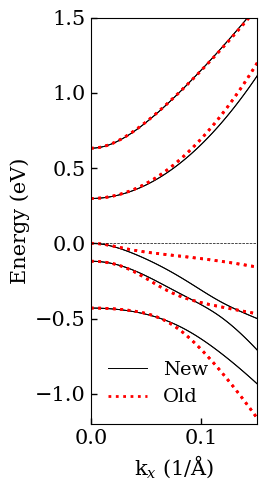

In [6]:
import matplotlib.pyplot as plt
plt.rcParams.update({'figure.autolayout': True})
plt.figure(figsize=(3, 5))
plt.rcParams["font.family"] = "DejaVu Serif"
plt.rcParams["mathtext.fontset"] = "dejavuserif"

nk = 100
div = 16
Mpoint = np.array([np.pi, 0.0, 0.0])
GM = np.array([[i, 0, 0] for i in np.arange(0, Mpoint[0] / div, Mpoint[0] / (div * nk))])
k_points = GM[:, 0]

# Compute eigenvalues for analytical model
eigvalsold = [eigh(H_kp(kx, ky, kz))[0] for kx, ky, kz in GM]
eigvalsnew = [eigh(Hhex(kx, ky, kz))[0] for kx, ky, kz in GM]

# === Plot kp model ===

# === Plot kp model ===
for i, band in enumerate(np.array(eigvalsnew).T):
    plt.plot(k_points, band, color="k",  ls ='-', lw=0.7, label="New" if i == 1 else "")
for i, band in enumerate(np.array(eigvalsold).T):
    plt.plot(k_points, band, color="r", ls =':', lw=2, label="Old" if i == 1 else "")

    
plt.axhline(y=0, color='black', ls='--', lw=0.5)
plt.xlabel("k$_x$ (1/Å)", fontsize=15)
plt.ylabel("Energy (eV)", fontsize=15)
plt.ylim(-1.2, 1.5)
plt.xlim(0.0, 0.15)
# plt.grid(True, linestyle='--', alpha=0.3)
plt.tick_params(direction='in', length=4, width=1, labelsize=15)
plt.legend(frameon=False, fontsize=14)

# plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.savefig("kp_old_vs_new.png", dpi=300)
plt.savefig("kp_old_vs_new.pdf", dpi=300)
plt.show()

